# 02 — Disk views (matplotlib)

Stereographic north/south, orthographic ``(x,y)`` after normalizing to ``S^2``, sampled PPI edges, optional Poincaré-disk geodesics (via half-plane model).

**Load run and build vertex index**

Reloads the chosen run (same `RUN_SUBDIR` / `DMERCATOR_RUN` convention as `00`) and builds `pos_idx` mapping protein name → row index for fast edge lookup in later cells.

In [9]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 200  # default 100; sharper inline figures
import networkx as nx
import numpy as np
import pandas as pd

import dmercator_io as dm

RUN_SUBDIR = "d2"
RUN_SUBDIR = os.environ.get("DMERCATOR_RUN", RUN_SUBDIR)
paths = dm.paths_for_run(RUN_SUBDIR)
_, df = dm.parse_inf_coord(paths["inf_coord"])
G = dm.load_edges_graph(paths["edge"])

uN, vN = dm.stereo_disk_north(df)
uS, vS = dm.stereo_disk_south(df)
xO, yO = dm.ortho_xy_disk(df)
pos_idx = {v: i for i, v in enumerate(df["Vertex"])}

# log10(degree+1) for scatter coloring (blue–red: seismic, low→high degree)
_deg = np.array([G.degree(str(v).strip()) for v in df["Vertex"]], dtype=float)
deg_log10 = np.log10(_deg + 1.0)
deg_log10_vmin = float(deg_log10.min())
deg_log10_vmax = float(deg_log10.max())


**Compare projection charts**

Three panels in **one column** (stacked) for a larger figure. Plots stereo north/south with a fixed spatial clip (tails extend far in stereo) and orthographic `(x,y)` on the unit disk from normalized sphere points. **Interpretation:** orthographic view keeps all points inside `|r|≤1`; stereo views emphasize neighborhoods away from the projection pole.

C:\Users\john\AppData\Local\Temp\ipykernel_22012\606368591.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


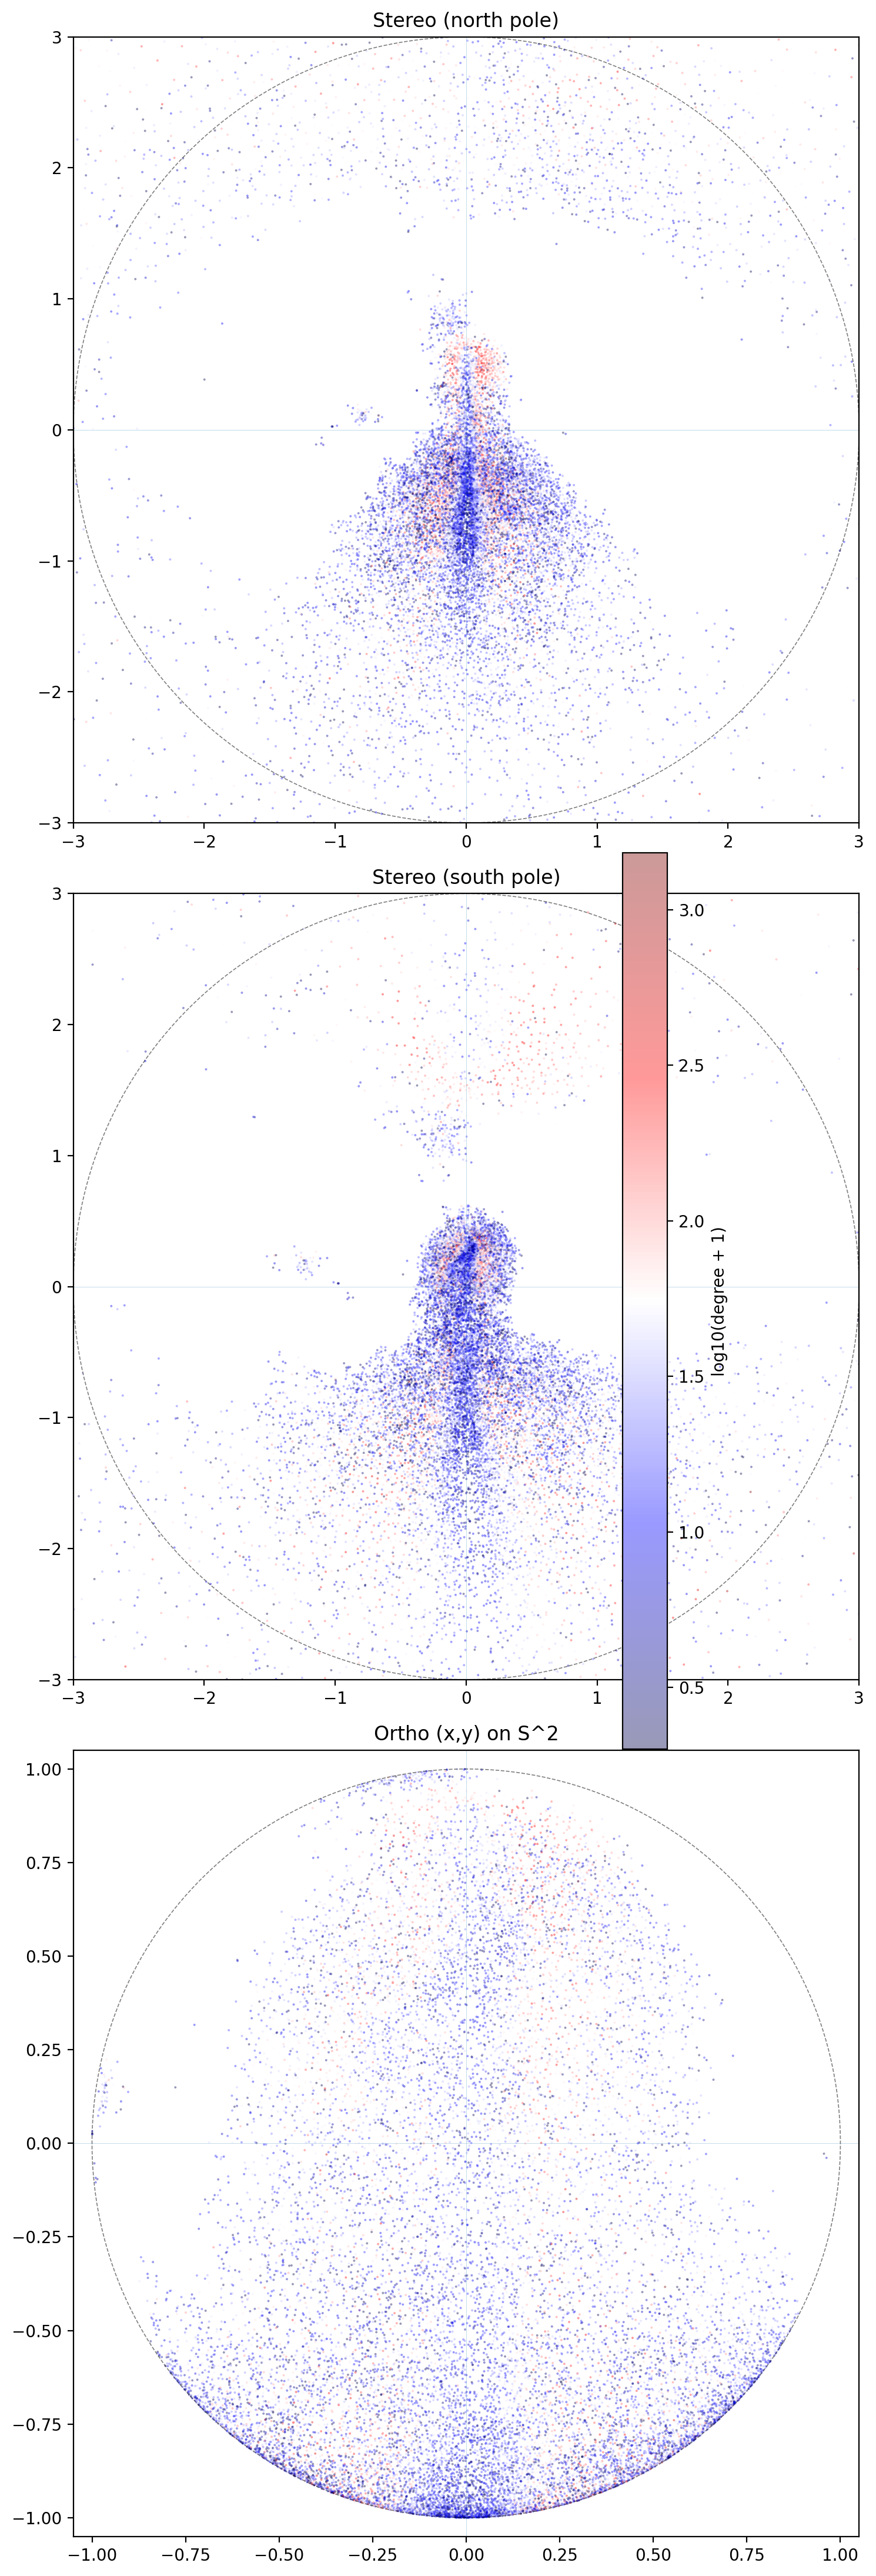

In [10]:
def plot_disk(ax, u, v, title, max_abs=None):
    sc = ax.scatter(
        u,
        v,
        s=2,
        alpha=0.4,
        c=deg_log10,
        cmap="seismic",
        vmin=deg_log10_vmin,
        vmax=deg_log10_vmax,
        linewidths=0,
        rasterized=True,
    )
    ax.set_aspect("equal")
    ax.set_title(title)
    if max_abs:
        ax.set_xlim(-max_abs, max_abs)
        ax.set_ylim(-max_abs, max_abs)
    ax.axhline(0, lw=0.3, alpha=0.3)
    ax.axvline(0, lw=0.3, alpha=0.3)
    return sc


# Clip stereo plots for readability (tails are long)
clip = 3.0
fig, axes = plt.subplots(3, 1, figsize=(10, 22))  # one column: larger panels
plot_disk(axes[0], uN, vN, "Stereo (north pole)", clip)
plot_disk(axes[1], uS, vS, "Stereo (south pole)", clip)
sc_last = plot_disk(axes[2], xO, yO, "Ortho (x,y) on S^2", 1.05)
for ax in axes[:2]:
    ax.add_patch(plt.Circle((0, 0), clip, fill=False, ls="--", lw=0.6, alpha=0.5))
axes[2].add_patch(plt.Circle((0, 0), 1.0, fill=False, ls="--", lw=0.6, alpha=0.5))
fig.colorbar(sc_last, ax=axes.ravel().tolist(), shrink=0.45, label="log10(degree + 1)")
plt.tight_layout()
plt.show()


**Interactive stereo clip (ipywidgets + matplotlib)**

The draggable control is an **ipywidgets** ``FloatSlider`` (works with the default **inline** Matplotlib backend). Each change redraws **one** matplotlib figure inside a single ``Output`` area (``display(fig)`` then ``plt.close(fig)``). Figures are built with ``matplotlib.figure.Figure`` plus ``FigureCanvasAgg`` instead of ``plt.subplots`` so the inline backend does not also flush the same figure to the cell output (which would stack duplicate images). ``matplotlib.widgets.Slider`` would need an interactive backend (e.g. ``pip install ipympl`` then ``%matplotlib widget``).

Install: ``pip install ipywidgets``. Slider **0.1–50** (step 0.1), default **10**. Run the **load** cell first.


In [11]:
# Interactive stereo clip — ipywidgets slider + matplotlib (works with inline backend)
# Build figures with Figure + Agg (not plt.subplots) so %matplotlib inline does not
# auto-flush the same figure to the cell output as well as the Output widget.
try:
    from ipywidgets import FloatSlider, VBox, Output
    from IPython.display import display
except ImportError as e:
    raise ImportError("pip install ipywidgets") from e

from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.patches import Circle

CLIP_INIT = 10.0
CLIP_MIN, CLIP_MAX, CLIP_STEP = 0.1, 50.0, 0.1

out = Output(layout={"border": "1px solid #ddd"})
out.clear_output(wait=True)

slider = FloatSlider(
    value=CLIP_INIT,
    min=float(CLIP_MIN),
    max=float(CLIP_MAX),
    step=float(CLIP_STEP),
    description="clip",
    continuous_update=False,
    readout_format=".2f",
)


def render(clip: float) -> None:
    clip = float(clip)
    out.clear_output(wait=True)
    with out:
        fig = Figure(figsize=(22, 7))
        FigureCanvasAgg(fig)
        ax_n, ax_s, ax_o = fig.subplots(1, 3)
        for ax, u, v, title in (
            (ax_n, uN, vN, "Stereo (north pole)"),
            (ax_s, uS, vS, "Stereo (south pole)"),
        ):
            ax.scatter(
                u,
                v,
                s=2,
                alpha=0.4,
                c=deg_log10,
                cmap="seismic",
                vmin=deg_log10_vmin,
                vmax=deg_log10_vmax,
                linewidths=0,
                rasterized=True,
            )
            ax.set_aspect("equal")
            ax.set_title(title)
            ax.axhline(0, lw=0.3, alpha=0.3)
            ax.axvline(0, lw=0.3, alpha=0.3)
            ax.set_xlim(-clip, clip)
            ax.set_ylim(-clip, clip)
            ax.add_patch(
                Circle((0, 0), clip, fill=False, ls="--", lw=0.6, alpha=0.5)
            )

        sc_o = ax_o.scatter(
            xO,
            yO,
            s=2,
            alpha=1,
            c=deg_log10,
            cmap="seismic",
            vmin=deg_log10_vmin,
            vmax=deg_log10_vmax,
            linewidths=0,
            rasterized=True,
        )
        ax_o.set_aspect("equal")
        ax_o.set_title("Ortho (x,y) on S^2")
        ax_o.set_xlim(-1.05, 1.05)
        ax_o.set_ylim(-1.05, 1.05)
        ax_o.axhline(0, lw=0.3, alpha=0.3)
        ax_o.axvline(0, lw=0.3, alpha=0.3)
        ax_o.add_patch(Circle((0, 0), 1.0, fill=False, ls="--", lw=0.6, alpha=0.5))

        fig.colorbar(sc_o, ax=[ax_n, ax_s, ax_o], shrink=0.55, label="log10(degree + 1)")
        fig.suptitle(f"Stereo |u|,|v| ≤ {clip:g} (ortho fixed)", y=1.02)
        fig.tight_layout(rect=[0, 0.06, 1, 0.96])
        display(fig)
        plt.close(fig)


def on_slider(change) -> None:
    render(float(change["new"]))


slider.observe(on_slider, names="value")
display(VBox([slider, out]))
render(float(slider.value))


**Poincaré-disk geodesics on sampled edges**

Maps orthographic disk coordinates to the upper half-plane, draws the unique hyperbolic segment, and maps back so each edge is a circular arc orthogonal to the unit circle (when endpoints lie strictly inside the disk). **Interpretation:** this visualizes *hyperbolic* proximity in the chosen 2D chart—not raw Euclidean distance in `Inf.Pos`.

In [13]:
# Poincaré disk ↔ upper half-plane, then the unique H² geodesic; map back to the disk.
# Run after the load cell (needs `numpy as np` from there). Defines `poincare_geodesic_xy`.


def _disk_to_upper(z: complex) -> complex:
    """Cayley-type map: open unit disk → upper half-plane (Im > 0)."""
    return 1j * (1 + z) / (1 - z)


def _upper_to_disk(w):
    """Inverse map: upper half-plane → unit disk."""
    return (w - 1j) / (w + 1j)


def _halfplane_geodesic_points(u1: complex, u2: complex, n: int):
    """Samples on the hyperbolic geodesic between u1 and u2 in the upper half-plane."""
    u1 = complex(u1)
    u2 = complex(u2)
    if abs(u1 - u2) < 1e-14:
        return np.array([u1], dtype=np.complex128)
    # Vertical geodesic when Re(u1) == Re(u2)
    if abs(u1.real - u2.real) < 1e-12 * (1.0 + abs(u1.imag) + abs(u2.imag)):
        im = np.linspace(u1.imag, u2.imag, n)
        return u1.real + 1j * im
    denom = 2.0 * (u2.real - u1.real)
    c = (abs(u2) ** 2 - abs(u1) ** 2) / denom + 0j
    r = float(abs(u1 - c))
    t1 = np.angle(u1 - c)
    t2 = np.angle(u2 - c)
    delta = (t2 - t1 + np.pi) % (2 * np.pi) - np.pi
    angles = t1 + np.linspace(0.0, float(delta), n)
    return c + r * np.exp(1j * angles)


def poincare_geodesic_xy(z1, z2, n: int = 48):
    """
    Cartesian samples of the Poincaré-disk geodesic between z1 and z2 (complex, |z| < 1).

    Returns (gx, gy) arrays for ``ax.plot(gx, gy, ...)``.
    """
    z1 = complex(z1)
    z2 = complex(z2)
    u1 = _disk_to_upper(z1)
    u2 = _disk_to_upper(z2)
    pts_h = _halfplane_geodesic_points(u1, u2, n)
    pts_d = _upper_to_disk(pts_h)
    return pts_d.real, pts_d.imag



seed nodes: ['CATSPER1', 'CYSRT1', 'CATSPERD', 'CACNA1H', 'STAC3', 'CACNB3', 'CACNG6', 'CACNA1S', 'CATSPER4', 'CACNG8', 'CACNG2', 'CACNA1C', 'KRTAP1-3', 'NOTCH2NLA', 'CACNG1', 'CACNA1F', 'CACNA2D1']
edges drawn: 1378


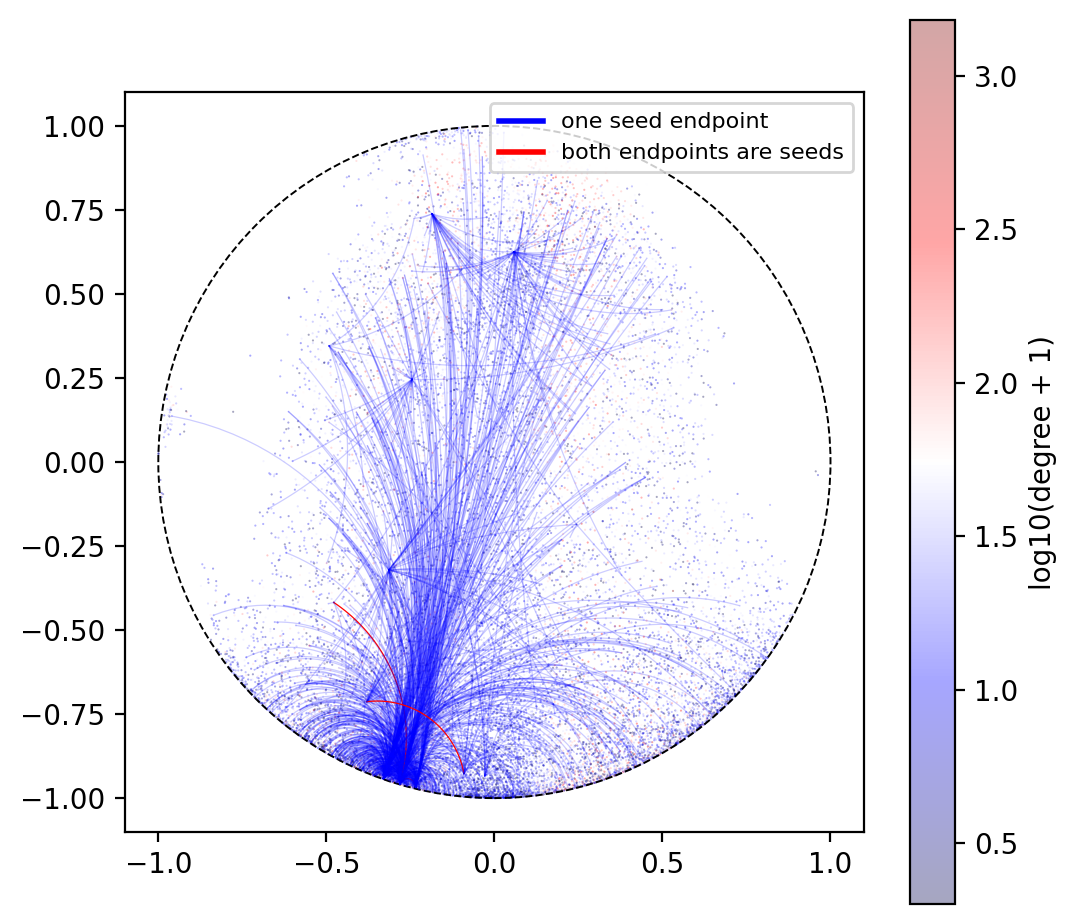

In [14]:
# Edges incident to SEED_NODES (run previous geodesic cell first for helpers + xO/yO/G/pos_idx)
from matplotlib.lines import Line2D
SEED_NODES = [
    "CATSPER1",
    "CYSRT1",
    "CATSPERD",
    "CACNA1H",
    "STAC3",
    "CACNB3",
    "CACNG6",
    "CACNA1S",
    "CATSPER4",
    "CACNG8",
    "CACNG2",
    "CACNA1C",
    "KRTAP1-3",
    "NOTCH2NLA",
    "CACNG1",
    "CACNA1F",
    "CACNA2D1",
]
seeds_valid = [str(n).strip() for n in SEED_NODES if str(n).strip()]
missing = [n for n in seeds_valid if n not in pos_idx]
seeds_ok = [n for n in seeds_valid if n in pos_idx]
seed_set = set(seeds_ok)
if missing:
    print("Unknown or missing from coord table (skipped):", missing)
if not seeds_ok:
    raise ValueError("No valid seed names — fix SEED_NODES to match graph vertices.")

edge_rows = []
for a, b in G.edges():
    if a not in pos_idx or b not in pos_idx:
        continue
    a_in, b_in = a in seed_set, b in seed_set
    if not (a_in or b_in):
        continue
    edge_rows.append((a, b, a_in and b_in))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
sc_bg = ax.scatter(
    xO,
    yO,
    s=0.6,
    alpha=0.35,
    c=deg_log10,
    cmap="seismic",
    vmin=deg_log10_vmin,
    vmax=deg_log10_vmax,
    linewidths=0,
    rasterized=True,
)
fig.colorbar(sc_bg, ax=ax, shrink=0.85, label="log10(degree + 1)")
col_single = "blue"
col_both = "red"
for a, b, both in edge_rows:
    ia, ib = pos_idx[a], pos_idx[b]
    z1 = complex(xO[ia], yO[ia])
    z2 = complex(xO[ib], yO[ib])
    if abs(z1) >= 0.999 or abs(z2) >= 0.999:
        continue
    gx, gy = poincare_geodesic_xy(z1, z2, n=48)
    ax.plot(gx, gy, lw=0.45, alpha=1 if both else 0.2, color=col_both if both else col_single)

ax.set_aspect("equal")
ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, ls="--", lw=0.7))
#ax.set_title("Poincaré geodesics — edges incident to " + ", ".join(seeds_ok))

ax.legend(
    handles=[
        Line2D([0], [0], color=col_single, lw=2, label="one seed endpoint"),
        Line2D([0], [0], color=col_both, lw=2, label="both endpoints are seeds"),
    ],
    loc="upper right",
    fontsize=8,
)
print("seed nodes:", seeds_ok)
print("edges drawn:", len(edge_rows))
plt.tight_layout()
plt.show()


**Poincaré geodesics — edges incident to chosen proteins**

Edit ``SEED_NODES`` (list of protein IDs matching the edgelist / ``Vertex`` names). The next cell draws **every** edge that has **at least one** endpoint in that set. Edges whose **both** endpoints are seeds are drawn in one color; edges with **exactly one** seed endpoint in another.

**Run the code cell above first** so ``poincare_geodesic_xy`` and the orthographic disk arrays ``xO``, ``yO``, ``pos_idx``, ``G`` exist.

seed nodes: ['GRB2', 'GIT1', 'OCRL']
edges drawn: 411


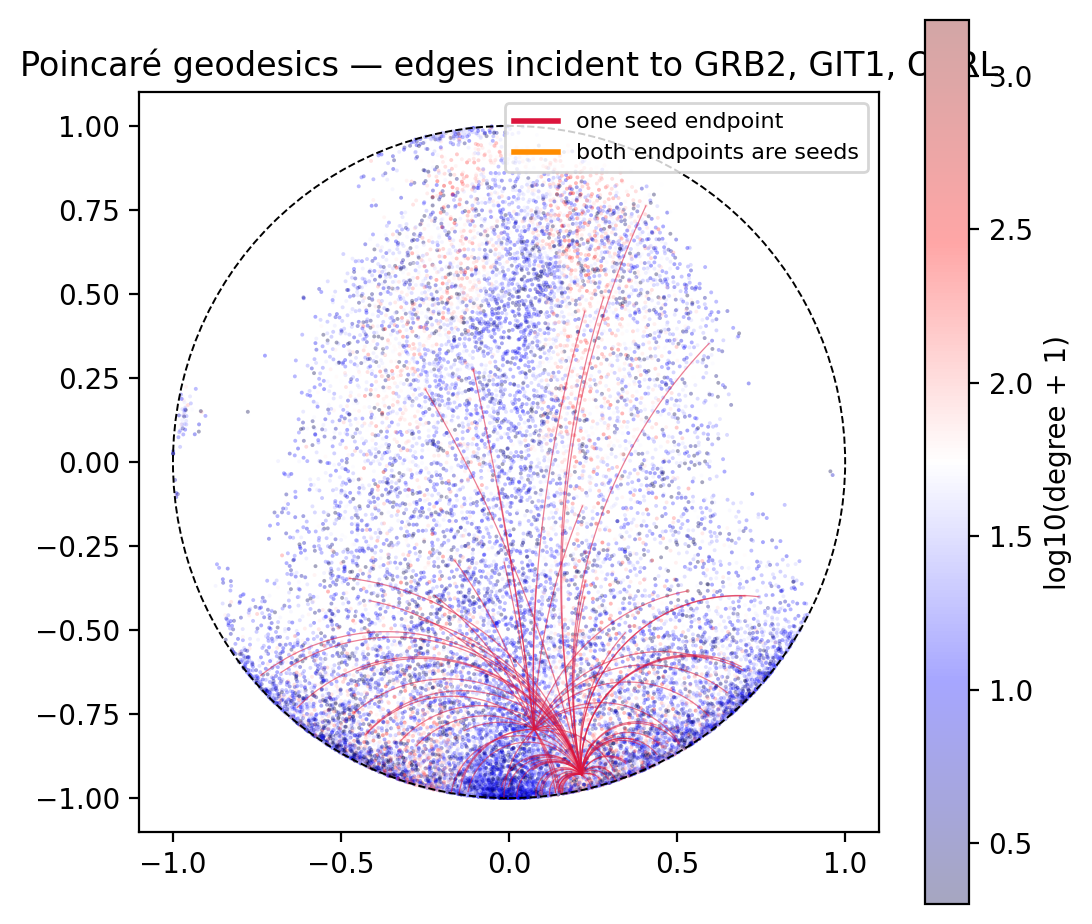

In [15]:
# Edges incident to SEED_NODES (run previous geodesic cell first for helpers + xO/yO/G/pos_idx)
from matplotlib.lines import Line2D
SEED_NODES = [
    "GRB2",
    "GIT1",
    "OCRL",
]

seeds_valid = [str(n).strip() for n in SEED_NODES if str(n).strip()]
missing = [n for n in seeds_valid if n not in pos_idx]
seeds_ok = [n for n in seeds_valid if n in pos_idx]
seed_set = set(seeds_ok)
if missing:
    print("Unknown or missing from coord table (skipped):", missing)
if not seeds_ok:
    raise ValueError("No valid seed names — fix SEED_NODES to match graph vertices.")

edge_rows = []
for a, b in G.edges():
    if a not in pos_idx or b not in pos_idx:
        continue
    a_in, b_in = a in seed_set, b in seed_set
    if not (a_in or b_in):
        continue
    edge_rows.append((a, b, a_in and b_in))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
sc_bg = ax.scatter(
    xO,
    yO,
    s=2,
    alpha=0.35,
    c=deg_log10,
    cmap="seismic",
    vmin=deg_log10_vmin,
    vmax=deg_log10_vmax,
    linewidths=0,
    rasterized=True,
)
fig.colorbar(sc_bg, ax=ax, shrink=0.85, label="log10(degree + 1)")
col_single = "crimson"
col_both = "darkorange"
for a, b, both in edge_rows:
    ia, ib = pos_idx[a], pos_idx[b]
    z1 = complex(xO[ia], yO[ia])
    z2 = complex(xO[ib], yO[ib])
    if abs(z1) >= 0.999 or abs(z2) >= 0.999:
        continue
    gx, gy = poincare_geodesic_xy(z1, z2, n=48)
    ax.plot(gx, gy, lw=0.45, alpha=0.55, color=col_both if both else col_single)

ax.set_aspect("equal")
ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, ls="--", lw=0.7))
ax.set_title("Poincaré geodesics — edges incident to " + ", ".join(seeds_ok))

ax.legend(
    handles=[
        Line2D([0], [0], color=col_single, lw=2, label="one seed endpoint"),
        Line2D([0], [0], color=col_both, lw=2, label="both endpoints are seeds"),
    ],
    loc="upper right",
    fontsize=8,
)
print("seed nodes:", seeds_ok)
print("edges drawn:", len(edge_rows))
plt.tight_layout()
plt.show()


**Local crop in south-stereo plane**

Keeps only points whose south-stereo complex coordinate lies near a chosen center (spatial window, not a true Möbius transform). **Interpretation:** zooms into one dense region; aspect ratio `equal` preserves local geometry in the plot.

In [ ]:
# Local window on south stereo (no Möbius numerics — just a spatial crop)
z = uS + 1j * vS
center = -0.15 + 0.05j
radius = 0.55
mask = np.abs(z - center) < radius
fig, ax = plt.subplots(figsize=(5, 5))
sc_loc = ax.scatter(
    uS[mask],
    vS[mask],
    s=2,
    alpha=0.45,
    c=deg_log10[mask],
    cmap="seismic",
    vmin=deg_log10_vmin,
    vmax=deg_log10_vmax,
    linewidths=0,
    rasterized=True,
)
fig.colorbar(sc_loc, ax=ax, shrink=0.85, label="log10(degree + 1)")
ax.set_aspect("equal")
ax.set_title("South stereo — local window")
plt.show()
